In [1]:
import numpy as np
import numpy as np
from jax import config
import sax
from simphony.libraries import siepic, sipann
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

# we are on notebook, so enable interactive mode for plotting
plt.ion()

config.update("jax_enable_x64", True)

/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/comp.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
I0000 00:00:1780748608.116935   73174 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780748609.510398   73174 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


INFO:tensorflow:Restoring parameters from /home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_GAP/model
INFO:tensorflow:Restoring parameters from /home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_STRAIGHT/model


/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/import_nn.py:125: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict_ = pickle.load(file)
E0000 00:00:1780748610.243206   73174 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


INFO:tensorflow:Restoring parameters from /home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_BENT_RAND/model


/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/import_nn.py:286: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict_ = pickle.load(file)
/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/scee.py:186: SyntaxWarning: invalid escape sequence '\ '
  """Abstract Class that all directional couplers inherit from. Each DC will
/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/scee.py:392: SyntaxWarning: invalid escape sequence '\ '
  """This class will create arbitrarily shaped SYMMETRIC (ie both waveguides
/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/scee.py:586: SyntaxWarning: invalid escape sequence '\ '
  """This class will create arbitrarily shaped ANTISYMMETRIC (ie waveguides
/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-

In [2]:
circuit, info = sax.circuit(
    netlist={
        "instances": {
            "ring_up": "half_ring",
            "ring_down": "half_ring",
        },
        "connections": {
            "ring_up,o1": "ring_down,o3",
            "ring_down,o1": "ring_up,o3",
        },
        "ports": {
            "in": "ring_up,o0",
            "through": "ring_up,o2",  # through port
            "drop": "ring_down,o2", # drop port
            "add": "ring_down,o0",  # add port
        }
    },
    models={
        "half_ring": partial(sipann.half_ring, width=500, thickness=220, gap=100),
    }
)

In [3]:
wls = np.linspace(1.55, 1.6, 100)
wls = np.array([1.58,1.581])
S = circuit(wl=wls, ring_up={"radius": 10}, ring_down={"radius": 10})

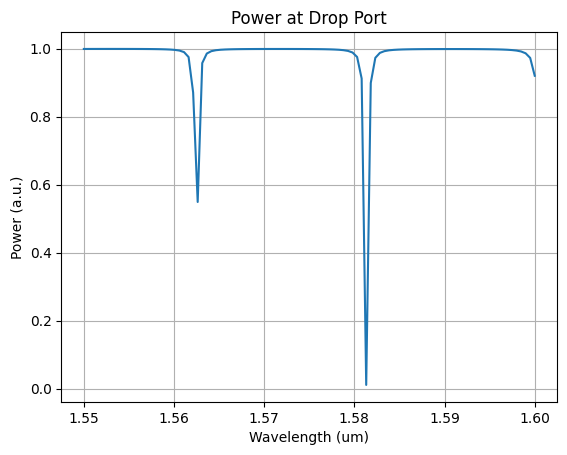

In [9]:
power = jnp.abs(S["through","in"])**2
plt.figure()
plt.plot(wls, power)
plt.xlabel("Wavelength (um)")
plt.ylabel("Power (a.u.)")
plt.title("Power at Drop Port")
plt.grid()

In [ ]:
circuit, info = sax.circuit(
    netlist={
        "instances": {
            "ring_up": "half_ring",
            "ring_down": "half_ring",
        },
        "connections": {
            "ring_up,o1": "ring_down,o3",
            "ring_down,o1": "ring_up,o3",
        },
        "ports": {
            "in": "ring_up,o0",
            "through": "ring_up,o2",  # through port
            "drop": "ring_down,o2", # drop port
            "add": "ring_down,o0",  # add port
        }
    },
    models={
        "half_ring": partial(sipann.half_ring, width=500, thickness=220, gap=100),
    }
)


/tmp/ipykernel_73174/3380030167.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


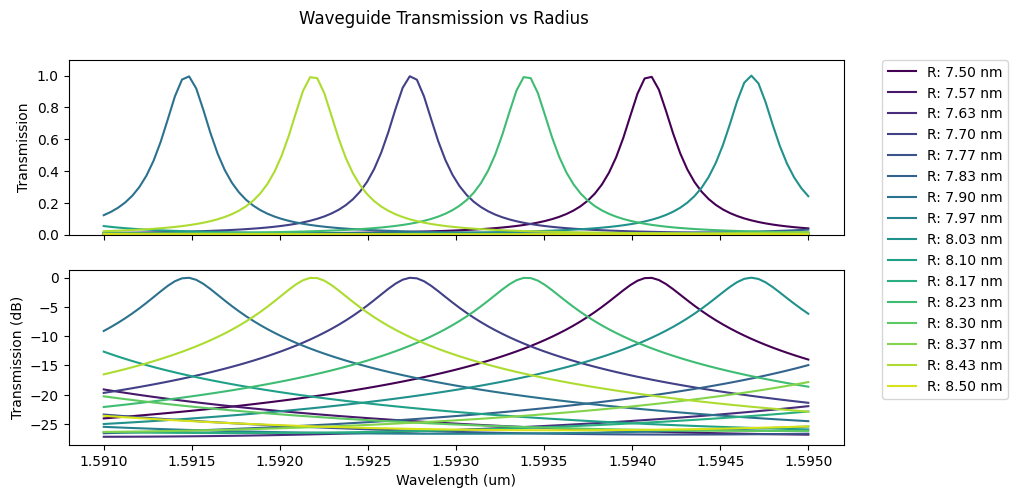

In [49]:
wls = np.linspace(1.591, 1.595, 100)
radii = np.linspace(7.5, 8.5, 16) # from 0.5 to 2 microns, 10 points

selected = ['7.50', '7.70', '7.90', '8.03', '8.23', '8.43']
selected_radii = [float(radius) for radius in selected]
# radii = selected_radii
results_per_radius = {}
for i, radius in enumerate(radii):
    S = circuit(wl=wls, ring_up={"radius": radius}, ring_down={"radius": radius})

    # Normalized power
    power = jnp.abs(S["drop","in"])**2
    # Loss
    if power.max() < 1e-6:
        loss = jnp.zeros_like(power)
    else:
        loss = 10*jnp.log10(power)
    
    radius_key = f"{radius:0.2f}"
    results_per_radius[radius_key] = {
        "wg_radius": radius,
        "power": power,
        "loss": loss,
    }

# Plot
# plot_transmission_db_plots(
#     results_per_radius, radii, wls, 
# )
# make plot twice as wide. And keep an empty padding to the right of the legend
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs[0].set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(radii)))))

for i, radius in enumerate(radii):
    radius_key = f"{radius:0.2f}"
    axs[0].plot(wls, results_per_radius[radius_key]["power"], label=f"R: {radius:0.2f} nm", color=cmap(i/len(radii)))
    axs[1].plot(wls, results_per_radius[radius_key]["loss"], label=f"R: {radius:0.2f} nm", color=cmap(i/len(radii)))

axs[0].set_ylim(0, 1.1)
axs[0].set_ylabel("Transmission")
axs[1].set_ylabel("Transmission (dB)")
axs[1].set_xlabel("Wavelength (um)")
# axs[1].legend()
axs[0].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.suptitle("Waveguide Transmission vs Radius")
fig.show()

In [50]:
results_per_radius
# keep all radius results which for the span, they have a loss of less than -5 dB
radii_with_loss = [results_per_radius[radius]["wg_radius"] for radius in results_per_radius.keys() if results_per_radius[radius]["loss"].max() > -5]
radii_with_loss

[np.float64(7.5),
 np.float64(7.7),
 np.float64(7.9),
 np.float64(8.033333333333333),
 np.float64(8.233333333333333),
 np.float64(8.433333333333334)]

/tmp/ipykernel_73174/2577427520.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


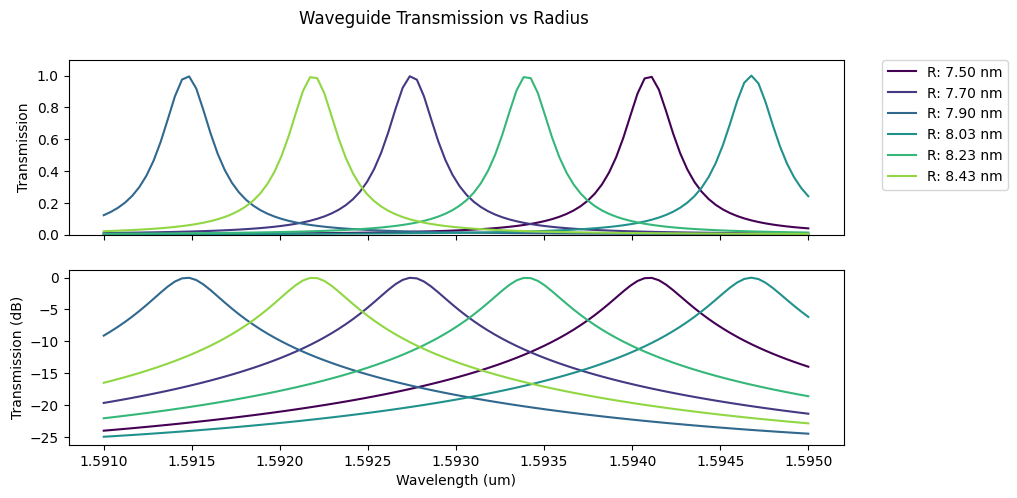

In [59]:
wls = np.linspace(1.591, 1.595, 100)
radii = np.linspace(7.5, 8.5, 16) # from 0.5 to 2 microns, 10 points

selected = ['7.50', '7.70', '7.90', '8.03', '8.23', '8.43']
selected_radii = [float(radius) for radius in selected]
radii = [np.float64(7.5),
 np.float64(7.7),
 np.float64(7.9),
 np.float64(8.033333333333333),
 np.float64(8.233333333333333),
 np.float64(8.433333333333334)]
results_per_radius = {}
for i, radius in enumerate(radii):
    S = circuit(wl=wls, ring_up={"radius": radius}, ring_down={"radius": radius})

    # Normalized power
    power = jnp.abs(S["drop","in"])**2
    # Loss
    if power.max() < 1e-6:
        loss = jnp.zeros_like(power)
    else:
        loss = 10*jnp.log10(power)
    
    radius_key = f"{radius:0.2f}"
    results_per_radius[radius_key] = {
        "wg_radius": radius,
        "power": power,
        "loss": loss,
    }

# Plot
# plot_transmission_db_plots(
#     results_per_radius, radii, wls, 
# )
# make plot twice as wide. And keep an empty padding to the right of the legend
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs[0].set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(radii)))))

for i, radius in enumerate(radii):
    radius_key = f"{radius:0.2f}"
    axs[0].plot(wls, results_per_radius[radius_key]["power"], label=f"R: {radius:0.2f} nm", color=cmap(i/len(radii)))
    axs[1].plot(wls, results_per_radius[radius_key]["loss"], label=f"R: {radius:0.2f} nm", color=cmap(i/len(radii)))

axs[0].set_ylim(0, 1.1)
axs[0].set_ylabel("Transmission")
axs[1].set_ylabel("Transmission (dB)")
axs[1].set_xlabel("Wavelength (um)")
# axs[1].legend()
axs[0].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.suptitle("Waveguide Transmission vs Radius")
fig.show()

In [45]:
results_per_radius
# keep all radius results which for the span, they have a loss of less than -5 dB
radii_with_loss = [radius for radius in results_per_radius.keys() if results_per_radius[radius]["loss"].max() > -5]
radii_with_loss

['7.50', '7.70', '7.90', '8.03', '8.23', '8.43']

In [44]:
keys = list(results_per_radius.keys())
results_per_radius[keys[0]]["loss"].max()

Array(-0.03363695, dtype=float64)